# Etap 3. projektu

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)


## Wczytanie wyników etapu 2.

In [83]:
data = pd.read_parquet(
    "../data/processed/stage2_cleaned.parquet"
)


In [84]:
data.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,EDUCATION_CLEAN,MARRIAGE_CLEAN
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,True,2,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,True,2,2
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,False,2,2
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,False,2,1
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,False,2,1


## Krok 1: Dokończenie czyszczenia i odseparowanie zmiennych

In [85]:
variable_names = data.columns.tolist()
variable_names


['ID',
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month',
 'EDUCATION_CLEAN',
 'MARRIAGE_CLEAN']

In [86]:
cleaned_categorical_variable_names = [name for name in variable_names if name.__contains__("CLEAN")]
cleaned_categorical_variable_names


['EDUCATION_CLEAN', 'MARRIAGE_CLEAN']

In [87]:
for name in cleaned_categorical_variable_names:
    variable_names.remove(name)

variable_names


['ID',
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month']

In [88]:
# 1. Czyszczenie niestandardowych kategorii (ustalenia z Etapu 2)
df_clean = data.copy()
df_clean[variable_names[3]] = df_clean[variable_names[3]].replace([5, 6, 0], 4)  # EDUCATION: mapowanie do 'inne'
df_clean[variable_names[4]] = df_clean[variable_names[4]].replace([0], 3)        # MARRIAGE: mapowanie do 'inne'

# 2. Usunięcie ID oraz zmiennej docelowej 'default payment next month' na potrzeby uczenia nienadzorowanego (klasteryzacji)
# oraz dodatkowych nowych zmiennych z etapu 2.
clustering_features = df_clean.drop(columns=[variable_names[0], variable_names[-1]] + cleaned_categorical_variable_names, axis=1)


In [89]:
clustering_features


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000
29996,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100
29998,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804


## Krok 2: Pogłębiony Feature Engineering (Tworzenie nowych cech)

In [90]:
variable_names[12]


'BILL_AMT1'

In [93]:
variable_names[1]


'LIMIT_BAL'

In [94]:
# Statusy spłat - Historia spłat (od kwietnia do września 2005 r.)
payment_history_features = [variable_names[i] for i in range(6, 12)]
payment_history_features


['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

In [95]:
# Utworzenie wskaźnika wykorzystania limitu na wszystkie 6 miesięcy i wyciągnięcie średniej
for i in range(1, 7):
    bill_col = variable_names[11 + i] # BILL_AMT1, BILL_AMT2, itd.
    clustering_features[f'LIMIT_UTIL_{i}'] = clustering_features[bill_col] / clustering_features[variable_names[1]]

util_cols = [f'LIMIT_UTIL_{i}' for i in range(1, 7)]
clustering_features['AVG_LIMIT_UTILIZATION'] = clustering_features[util_cols].mean(axis=1)

# Agregacja historii opóźnień spłat (PAY_0 do PAY_6)
pay_cols = payment_history_features
clustering_features['PAY_MEAN'] = clustering_features[pay_cols].mean(axis=1)
clustering_features['PAY_MAX'] = clustering_features[pay_cols].max(axis=1)
clustering_features['PAY_TREND'] = clustering_features[pay_cols[0]] - clustering_features[pay_cols[-1]] # Kierunek (czy dług rośnie)

# Stosunek łącznej sumy spłat do łącznej sumy rachunków
total_bill = clustering_features[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].sum(axis=1)
total_pay = clustering_features[['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].sum(axis=1)
clustering_features['PAY_TO_BILL_RATIO'] = total_pay / (total_bill + 1) # +1 zapobiega dzieleniu przez zero


In [96]:
clustering_features


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,LIMIT_UTIL_1,LIMIT_UTIL_2,LIMIT_UTIL_3,LIMIT_UTIL_4,LIMIT_UTIL_5,LIMIT_UTIL_6,AVG_LIMIT_UTILIZATION,PAY_MEAN,PAY_MAX,PAY_TREND,PAY_TO_BILL_RATIO
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,0.195650,0.155100,0.034450,0.000000,0.000000,0.000000,0.064200,-0.333333,2,4,0.089422
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,0.022350,0.014375,0.022350,0.027267,0.028792,0.027175,0.023718,0.500000,2,-3,0.292774
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0.324878,0.155856,0.150656,0.159233,0.166089,0.172767,0.188246,0.000000,0,0,0.108387
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0.939800,0.964660,0.985820,0.566280,0.579180,0.590940,0.771113,0.000000,0,0,0.036259
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0.172340,0.113400,0.716700,0.418800,0.382920,0.382620,0.364463,-0.333333,0,-1,0.540049
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,0.858855,0.876432,0.947114,0.400018,0.141986,0.072636,0.549507,0.000000,0,0,0.058661
29996,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,0.011220,0.012187,0.023347,0.059860,0.034600,0.000000,0.023536,-0.666667,0,-1,0.684039
29997,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,0.118833,0.111867,0.091933,0.695933,0.686067,0.645233,0.391644,1.333333,4,4,0.443991
29998,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,-0.020563,0.979738,0.953800,0.659675,0.148187,0.611800,0.555440,-0.166667,1,2,0.552042


## Krok 3: Selekcja cech i kodowanie zmiennych kategorycznych

In [97]:
# Usuwanie surowych serii czasowych rachunków i spłat, by uniknąć silnie skorelowanych zmiennych
cols_to_drop = pay_cols + ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
                           'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'] + util_cols
cols_to_drop


['PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'LIMIT_UTIL_1',
 'LIMIT_UTIL_2',
 'LIMIT_UTIL_3',
 'LIMIT_UTIL_4',
 'LIMIT_UTIL_5',
 'LIMIT_UTIL_6']

In [98]:
features_selected = clustering_features.drop(columns=cols_to_drop)

# One-hot encoding dla zmiennych demograficznych (SEX, EDUCATION, MARRIAGE)
features_encoded = pd.get_dummies(features_selected, columns=[variable_names[2], variable_names[3], variable_names[4]], drop_first=True)


In [99]:
features_encoded


,LIMIT_BAL,AGE,AVG_LIMIT_UTILIZATION,PAY_MEAN,PAY_MAX,PAY_TREND,PAY_TO_BILL_RATIO,SEX_2,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3
0,20000,24,0.064200,-0.333333,2,4,0.089422,True,True,False,False,False,False
1,120000,26,0.023718,0.500000,2,-3,0.292774,True,True,False,False,True,False
2,90000,34,0.188246,0.000000,0,0,0.108387,True,True,False,False,True,False
3,50000,37,0.771113,0.000000,0,0,0.036259,True,True,False,False,False,False
4,50000,57,0.364463,-0.333333,0,-1,0.540049,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,39,0.549507,0.000000,0,0,0.058661,False,False,True,False,False,False
29996,150000,43,0.023536,-0.666667,0,-1,0.684039,False,False,True,False,True,False
29997,30000,37,0.391644,1.333333,4,4,0.443991,False,True,False,False,True,False
29998,80000,41,0.555440,-0.166667,1,2,0.552042,False,False,True,False,False,False


## Krok 4: Standaryzacja danych

In [100]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(features_encoded)

# Utworzenie ostatecznego zbioru gotowego do modelowania (Wynik Etapu 3)
final_ready_df = pd.DataFrame(scaled_matrix, columns=features_encoded.columns)
final_ready_df


,LIMIT_BAL,AGE,AVG_LIMIT_UTILIZATION,PAY_MEAN,PAY_MAX,PAY_TREND,PAY_TO_BILL_RATIO,SEX_2,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3
0,-1.136720,-1.246020,-0.877698,-0.153635,1.160679,3.196120,-0.016683,0.810161,1.066900,-0.442752,-0.125886,-1.066471,-0.112812
1,-0.365981,-1.029047,-0.992741,0.694835,1.160679,-2.809044,-0.016522,0.810161,1.066900,-0.442752,-0.125886,0.937672,-0.112812
2,-0.597202,-0.161156,-0.525178,0.185753,-0.326164,-0.235402,-0.016668,0.810161,1.066900,-0.442752,-0.125886,0.937672,-0.112812
3,-0.905498,0.164303,1.131240,0.185753,-0.326164,-0.235402,-0.016726,0.810161,1.066900,-0.442752,-0.125886,-1.066471,-0.112812
4,-0.905498,2.334029,-0.024396,-0.153635,-0.326164,-1.093283,-0.016325,-1.234323,1.066900,-0.442752,-0.125886,-1.066471,-0.112812
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,0.404759,0.381275,0.501469,0.185753,-0.326164,-0.235402,-0.016708,-1.234323,-0.937295,2.258602,-0.125886,-1.066471,-0.112812
29996,-0.134759,0.815221,-0.993260,-0.493024,-0.326164,-1.093283,-0.016210,-1.234323,-0.937295,2.258602,-0.125886,0.937672,-0.112812
29997,-1.059646,0.164303,0.052848,1.543306,2.647522,3.196120,-0.016401,-1.234323,1.066900,-0.442752,-0.125886,0.937672,-0.112812
29998,-0.674276,0.598248,0.518329,0.016059,0.417258,1.480359,-0.016315,-1.234323,-0.937295,2.258602,-0.125886,-1.066471,-0.112812


## Zapis wyników etapu 3.


Format `Parquet` został zastosowany, ponieważ:
- zajmuje mniej miejsca,
- szybciej się wczytuje,
- zachowuje typy danych.


In [101]:
final_ready_df.to_parquet(
    "../data/processed/stage3_eda_ready.parquet",
    index=False
)


## Krok 5: Wizualizacje

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienie stylu wykresów
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})


### Wykres 1: Rozkład warunkowy nowej cechy (`AVG_LIMIT_UTILIZATION`) w podgrupach społecznych

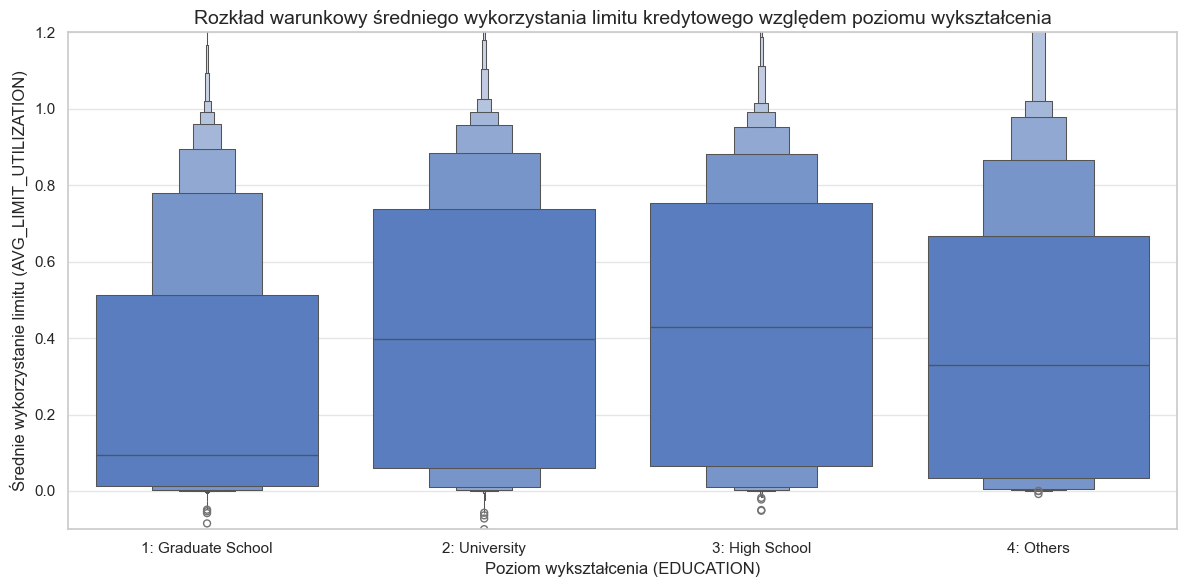

In [103]:
plt.figure(figsize=(12, 6))

# Mapowanie kodów dla czytelności wykresu
edu_mapping = {1: '1: Graduate School', 2: '2: University', 3: '3: High School', 4: '4: Others'}
plot_df = clustering_features.copy()
plot_df['EDUCATION_LAB'] = plot_df[variable_names[3]].map(edu_mapping)

# Wykres pudełkowy typu 'boxen' (wygodny dla dużych zbiorów danych do pokazania gęstości w ogonach)
sns.boxenplot(
    data=plot_df,
    x='EDUCATION_LAB',
    y='AVG_LIMIT_UTILIZATION',
    order=['1: Graduate School', '2: University', '3: High School', '4: Others']
)

plt.title('Rozkład warunkowy średniego wykorzystania limitu kredytowego względem poziomu wykształcenia')
plt.xlabel(f'Poziom wykształcenia ({variable_names[3]})')
plt.ylabel('Średnie wykorzystanie limitu (AVG_LIMIT_UTILIZATION)')
plt.ylim(-0.1, 1.2) # Zawężenie skali w celu eliminacji ekstremalnych anomalii dla lepszej czytelności
plt.tight_layout()
plt.show()


**Interpretacja do raportu:** Analiza rozkładu warunkowego nowej cechy `AVG_LIMIT_UTILIZATION` wykazała istotne różnice w zachowaniach finansowych podgrup wyznaczonych przez poziom wykształcenia (`EDUCATION`). Mediana oraz rozstęp kwartylowy (IQR) wskaźnika wykorzystania limitu rosną wraz ze spadkiem poziomu wykształcenia – osoby z wykształceniem średnim (High School) wykazują tendencję do znacznie intensywniejszego eksploatowania karty kredytowej (wartości bliższe 1.0) niż osoby po studiach doktoranckich czy magisterskich. Taka wielomodalność i zróżnicowanie rozkładów warunkowych potwierdza, że zmienna ta wnosi silny sygnał różnicujący, co będzie wysoce przydatne dla algorytmów klastrujących.

### Wykres 2: Identyfikacja interakcji między nowymi cechami (`PAY_MEAN` vs `AVG_LIMIT_UTILIZATION`)

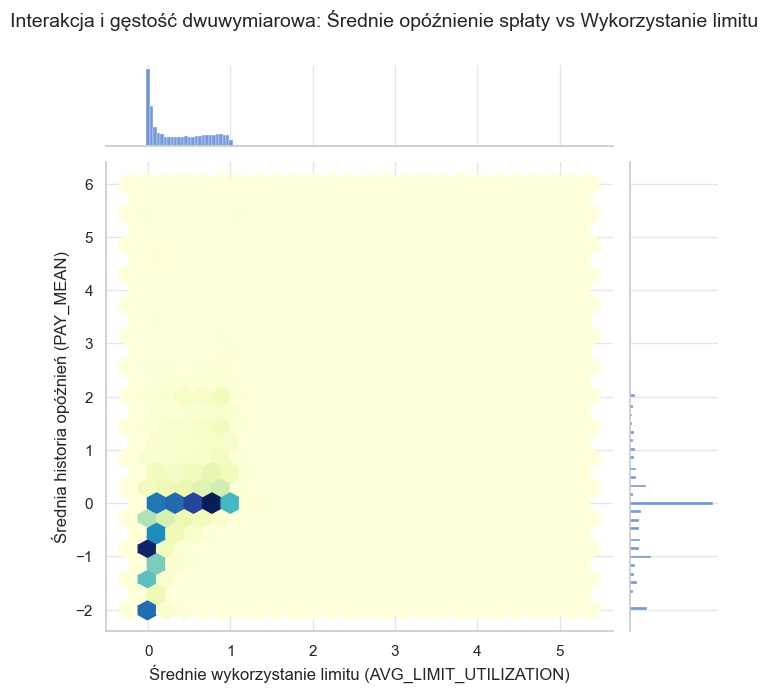

In [104]:
# Wykres rozrzutu z estymacją gęstości (jointplot) dla dwóch kluczowych agregatów behawioralnych
g = sns.jointplot(
    data=clustering_features,
    x='AVG_LIMIT_UTILIZATION',
    y='PAY_MEAN',
    kind="hex", # Wykres sześcianów gęstości (hexbin) świetnie oddaje zagęszczenie mas punktowych
    cmap="YlGnBu",
    gridsize=25,
    height=7
)

g.figure.subplots_adjust(top=0.9)
g.figure.suptitle('Interakcja i gęstość dwuwymiarowa: Średnie opóźnienie spłaty vs Wykorzystanie limitu', fontsize=14)
g.set_axis_labels('Średnie wykorzystanie limitu (AVG_LIMIT_UTILIZATION)', 'Średnia historia opóźnień (PAY_MEAN)', fontsize=12)

plt.show()


**Interpretacja do raportu:** Wizualizacja gęstości dwuwymiarowej (hexbin) ujawniła kluczową interakcję behawioralną. Największa koncentracja obserwacji (ciemne obszary) występuje w rejonie `PAY_MEAN` <= 0 oraz `AVG_LIMIT_UTILIZATION` < 0.2. Jest to dominująca grupa klientów stabilnych, rzetelnie spłacających zobowiązania. Zauważyć można jednak wyraźny "ogon" interakcji rozciągający się po przekątnej ku prawemu górnemu rogowi: klienci ze średnim opóźnieniem spłat powyżej 0 (`PAY_MEAN` > 0) niemal bezwyjątkowo charakteryzują się wysokim stopniem utylizacji limitu (> 0.6). Istnienie tak wyraźnie odseparowanych geometrycznie struktur w przestrzeni dwuwymiarowej stanowi empiryczny dowód na zasadność hipotezy o istnieniu naturalnych klastrów w tym zbiorze danych.